# QIntern 2026 — QTagger+
## Team B — Unified Days 4–7 experimental notebook

**Dataset:** CIC-MalMem-2022  
**Target family:** Trojan  
**Execution profile:** Fast, reproducible, CPU-friendly

### Workflow

- **Day 4:** compare QGAN raw, QGAN constrained, CTGAN-v2 and SMOTE fidelity;
- **Day 5:** benchmark Random Forest, XGBoost, LightGBM and linear SVM on Original, SMOTE, CTGAN-v2 and QGAN-augmented data;
- **Day 6:** run three small four-epoch QGAN ablations on 256 real Trojan observations;
- **Day 7:** consolidate results, figures.

In [2]:
# %pip install -q "umap-learn==0.5.7" openpyxl xgboost lightgbm pennylane

In [3]:
from pathlib import Path
import hashlib
import json
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from scipy.spatial.distance import cdist, pdist, squareform
from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED = 42
TARGET = "Label"
TARGET_CLASS = "Trojan"
N_EVAL = 2000
OUTPUT_DIR = Path("outputs_days4_7")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

pandas: 3.0.3
scikit-learn: 1.4.2


## 1. Required files

Upload the following files to `/content`, place them beside the notebook, or edit the candidate paths:

- complete `MalMem2022.csv` used on Day 3;
- `qgan_day3_preprocessing.joblib`;
- `qgan_day3_summary.json`;
- `qgan_day3_component_diagnostics.csv`;
- `qgan_day3_synthetic_raw_reconstructed.csv`;
- `qgan_day3_synthetic_constrained.csv`;
- the Week 2 SMOTE dataset; and
- the Week 2 CTGAN-v2 dataset.

Classical augmentation files may contain synthetic rows only or a complete balanced dataset containing real plus synthetic rows. The extraction audit below handles both cases and records its decision.

In [4]:
SEARCH_ROOTS = [
    Path("."),
    Path("/content"),
    Path("/content/drive/MyDrive"),
    Path("/content/drive/MyDrive/QTagger_Plus_Week1/data"),
    Path("/content/drive/MyDrive/qintern/week3/day3"),
]

FILE_CANDIDATES = {
    "real": ["MalMem2022.csv"],
    "preprocessing": ["qgan_day3_preprocessing.joblib"],
    "day3_summary": ["qgan_day3_summary.json"],
    "day3_components": ["qgan_day3_component_diagnostics.csv"],
    "qgan_raw": ["qgan_day3_synthetic_raw_reconstructed.csv"],
    "qgan_constrained": ["qgan_day3_synthetic_constrained.csv"],
    "smote": [
        "MalMem2022_SMOTE.csv", "MalMem2022_SMOTE.xlsx",
        "malmem_smote.csv", "malmem_smote.xlsx",
    ],
    "ctgan": [
        "MalMem2022_CTGAN_balanced.csv", "MalMem2022_CTGAN_balanced.xlsx",
        "malmem_ctgan.csv", "malmem_ctgan.xlsx",
        "MalMem2022_CTGAN_v2.csv", "MalMem2022_CTGAN_v2.xlsx",
    ],
}

def find_candidate(names):
    for root in SEARCH_ROOTS:
        for name in names:
            direct = root / name
            if direct.exists():
                return direct
    for root in SEARCH_ROOTS:
        if root.exists() and root.is_dir():
            for name in names:
                matches = list(root.rglob(name))
                if matches:
                    return matches[0]
    return None

PATHS = {key: find_candidate(names) for key, names in FILE_CANDIDATES.items()}
display(pd.Series({key: str(value) if value else "NOT FOUND" for key, value in PATHS.items()}, name="path"))

missing = [key for key, value in PATHS.items() if value is None]
if missing:
    raise FileNotFoundError(
        "Missing required Day 4 inputs: " + ", ".join(missing) +
        ". Upload them to /content or edit FILE_CANDIDATES."
    )

real                                           MalMem2022.csv
preprocessing                  qgan_day3_preprocessing.joblib
day3_summary                           qgan_day3_summary.json
day3_components           qgan_day3_component_diagnostics.csv
qgan_raw            qgan_day3_synthetic_raw_reconstructed.csv
qgan_constrained          qgan_day3_synthetic_constrained.csv
smote                                    MalMem2022_SMOTE.csv
ctgan                           MalMem2022_CTGAN_balanced.csv
Name: path, dtype: str

## 2. Load and verify Day 3 lineage

The complete real dataset must match the SHA-256 hash recorded on Day 3. This prevents accidental evaluation against the incomplete 50,515-row copy.

In [5]:
def sha256_file(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with open(path, "rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()

with open(PATHS["day3_summary"], encoding="utf-8") as file:
    day3_summary = json.load(file)

expected_hash = day3_summary["dataset_manifest"]["sha256"]
observed_hash = sha256_file(PATHS["real"])
assert observed_hash == expected_hash, (
    "Real dataset hash does not match Day 3. "
    f"Expected {expected_hash}, observed {observed_hash}."
)

preprocessing = joblib.load(PATHS["preprocessing"])
day3_components = pd.read_csv(PATHS["day3_components"])

kept_features = list(preprocessing["kept_features"])
feature_min = np.asarray(preprocessing["feature_min"])
feature_max = np.asarray(preprocessing["feature_max"])
imputer_medians_kept = np.asarray(preprocessing["imputer"].statistics_)[
    np.asarray(preprocessing["keep_mask"], dtype=bool)
]

print("Dataset hash: PASSED")
print("Day 3 clean shape:", day3_summary["dataset_manifest"]["clean_shape"])
print("Retained features:", len(kept_features))
print("Day 3 mean KS:", day3_summary["mean_ks_statistic"])
print("Day 3 mean Wasserstein:", day3_summary["mean_wasserstein_distance"])

Dataset hash: PASSED
Day 3 clean shape: [58062, 59]
Retained features: 52
Day 3 mean KS: 0.8386250000000001
Day 3 mean Wasserstein: 0.4593275494965107


## 3. Reconstruct the exact Day 3 real reference

The real dataset is cleaned and split using the same code, proportions and seed as Day 3. The same random number generator then selects the same 2,000 Trojan training positions. An assertion compares the reconstructed scaled-PC means with the saved Day 3 component diagnostics.

In [6]:
def load_table(path):
    suffix = path.suffix.lower()
    if suffix == ".csv":
        frame = pd.read_csv(path)
    elif suffix in {".xlsx", ".xls"}:
        frame = pd.read_excel(path)
    else:
        raise ValueError(f"Unsupported table format: {path}")
    frame.columns = frame.columns.astype(str).str.strip()
    return frame

def normalize_label_value(value):
    text = str(value).strip()
    if text.lower() == "benign":
        return "Benign"
    for family in ["Ransomware", "Spyware", "Trojan"]:
        if text.lower().startswith(family.lower()):
            return family
    return text

def ensure_label(frame):
    frame = frame.copy()
    candidates = ["Label", "Category", "Class", "label", "category", "class"]
    available = [column for column in candidates if column in frame.columns]
    if not available:
        raise KeyError(f"No label column found. Columns: {frame.columns.tolist()}")

    recognized_families = {"Benign", "Ransomware", "Spyware", "Trojan"}
    best_column = None
    best_normalized = None
    best_score = (-1, -1)

    for column in available:
        normalized = frame[column].map(normalize_label_value)
        represented = len(set(normalized.dropna().unique()) & recognized_families)
        target_count = int(normalized.eq(TARGET_CLASS).sum())
        score = (represented, target_count)
        if score > best_score:
            best_column = column
            best_normalized = normalized
            best_score = score

    frame[TARGET] = best_normalized
    print(
        f"Label source selected: {best_column} | "
        f"families={best_score[0]} | {TARGET_CLASS} rows={best_score[1]}"
    )
    return frame

real_raw = ensure_label(load_table(PATHS["real"]))
real_clean = real_raw.dropna(subset=[TARGET]).drop_duplicates().reset_index(drop=True)

assert len(real_clean) == day3_summary["dataset_manifest"]["clean_shape"][0]

all_idx = np.arange(len(real_clean))
train_val_idx, test_idx = train_test_split(
    all_idx, test_size=0.15, stratify=real_clean[TARGET], random_state=SEED
)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.15 / 0.85,
    stratify=real_clean.loc[train_val_idx, TARGET],
    random_state=SEED,
)

train_frame = real_clean.loc[train_idx].reset_index(drop=True)
real_trojan_train = train_frame[train_frame[TARGET].eq(TARGET_CLASS)].reset_index(drop=True)

rng = np.random.default_rng(SEED)
selected_positions = rng.choice(len(real_trojan_train), size=N_EVAL, replace=False)
real_reference = real_trojan_train.iloc[selected_positions].reset_index(drop=True)

print("Train rows:", len(train_frame))
print("Available Trojan train rows:", len(real_trojan_train))
print("Evaluation reference:", real_reference.shape)

Label source selected: Category | families=4 | Trojan rows=9487
Train rows: 40642
Available Trojan train rows: 6641
Evaluation reference: (2000, 59)


In [7]:
def align_features(frame):
    aligned = pd.DataFrame(index=frame.index)
    missing_features = []
    for position, feature in enumerate(kept_features):
        if feature in frame.columns:
            aligned[feature] = pd.to_numeric(frame[feature], errors="coerce")
        else:
            aligned[feature] = imputer_medians_kept[position]
            missing_features.append(feature)
    aligned = aligned.fillna(pd.Series(imputer_medians_kept, index=kept_features))
    return aligned.astype(float), missing_features

def to_shared_spaces(frame):
    aligned, missing_features = align_features(frame)
    standard = preprocessing["standard_scaler"].transform(aligned)
    pca_values = preprocessing["pca"].transform(standard)
    scaled_pca = preprocessing["qgan_scaler"].transform(pca_values)
    return aligned, standard, pca_values, scaled_pca, missing_features

real_features, real_standard, real_pca, real_scaled_pca, missing_real = to_shared_spaces(real_reference)
assert not missing_real

saved_real_means = day3_components.sort_values("component")["real_mean"].to_numpy()
reconstructed_real_means = real_scaled_pca.mean(axis=0)
np.testing.assert_allclose(reconstructed_real_means, saved_real_means, atol=2e-5)

print("Exact Day 3 real-reference reconstruction: PASSED")
print("Scaled-PC means:", np.round(reconstructed_real_means, 6))

Exact Day 3 real-reference reconstruction: PASSED
Scaled-PC means: [-0.36414  -0.754832 -0.663471  0.199589 -0.001574 -0.255841 -0.491424
 -0.782021]


## 4. Extract synthetic observations from each method

Extraction rules are applied in this order:

1. select the Trojan family;
2. use a `Source` column when it explicitly identifies synthetic rows;
3. otherwise remove rows that exactly match real CIC-MalMem Trojan feature rows;
4. if no real matches exist, treat the target rows as a synthetic-only export and record that assumption; and
5. sample exactly 2,000 rows with seed 42.

The provenance table must be inspected before accepting the comparison.

In [8]:
def stable_feature_hashes(frame, decimals=8):
    aligned, _ = align_features(frame)
    rounded = aligned.round(decimals)
    return pd.util.hash_pandas_object(rounded, index=False).to_numpy()

all_real_trojan = real_clean[real_clean[TARGET].eq(TARGET_CLASS)].reset_index(drop=True)
real_hash_set = set(stable_feature_hashes(all_real_trojan))

def extract_method(path, method_name, n=N_EVAL):
    loaded = ensure_label(load_table(path))
    target_rows = loaded[loaded[TARGET].eq(TARGET_CLASS)].copy().reset_index(drop=True)
    if len(target_rows) == 0:
        raise ValueError(f"No Trojan rows found in {method_name}: {path}")

    extraction_rule = None
    synthetic_rows = None

    source_column = next((c for c in target_rows.columns if c.lower() == "source"), None)
    if source_column is not None:
        source_text = target_rows[source_column].astype(str).str.lower()
        explicit_mask = source_text.str.contains("synthetic|smote|ctgan|qgan", regex=True)
        if explicit_mask.any():
            synthetic_rows = target_rows[explicit_mask].reset_index(drop=True)
            extraction_rule = "explicit Source flag"

    if synthetic_rows is None:
        hashes = stable_feature_hashes(target_rows)
        is_exact_real = np.array([value in real_hash_set for value in hashes])
        n_exact_real = int(is_exact_real.sum())
        if n_exact_real > 0:
            synthetic_rows = target_rows[~is_exact_real].reset_index(drop=True)
            extraction_rule = f"removed {n_exact_real} exact real Trojan rows"
        else:
            synthetic_rows = target_rows.reset_index(drop=True)
            extraction_rule = "no exact real matches; assumed synthetic-only export"

    if len(synthetic_rows) < n:
        raise ValueError(
            f"{method_name} has only {len(synthetic_rows)} extracted synthetic Trojan rows; {n} required."
        )

    sampled = synthetic_rows.sample(n=n, random_state=SEED).reset_index(drop=True)
    aligned, missing_features = align_features(sampled)
    provenance = {
        "method": method_name,
        "file": str(path),
        "loaded_rows": int(len(loaded)),
        "loaded_trojan_rows": int(len(target_rows)),
        "extracted_synthetic_trojan_rows": int(len(synthetic_rows)),
        "sampled_rows": int(len(sampled)),
        "extraction_rule": extraction_rule,
        "missing_features_imputed": missing_features,
    }
    return sampled, aligned, provenance

qgan_raw_loaded = ensure_label(load_table(PATHS["qgan_raw"]))
qgan_constrained_loaded = ensure_label(load_table(PATHS["qgan_constrained"]))

qgan_raw = qgan_raw_loaded[qgan_raw_loaded[TARGET].eq(TARGET_CLASS)].sample(
    n=N_EVAL, random_state=SEED
).reset_index(drop=True)
qgan_constrained = qgan_constrained_loaded[
    qgan_constrained_loaded[TARGET].eq(TARGET_CLASS)
].sample(n=N_EVAL, random_state=SEED).reset_index(drop=True)

qgan_raw_features, qgan_raw_missing = align_features(qgan_raw)
qgan_constrained_features, qgan_constrained_missing = align_features(qgan_constrained)

smote_rows, smote_features, smote_provenance = extract_method(PATHS["smote"], "SMOTE")
ctgan_rows, ctgan_features, ctgan_provenance = extract_method(PATHS["ctgan"], "CTGAN-v2")

provenance = [
    {
        "method": "QGAN raw",
        "file": str(PATHS["qgan_raw"]),
        "loaded_rows": len(qgan_raw_loaded),
        "loaded_trojan_rows": len(qgan_raw),
        "extracted_synthetic_trojan_rows": len(qgan_raw),
        "sampled_rows": len(qgan_raw),
        "extraction_rule": "Day 3 raw synthetic export",
        "missing_features_imputed": qgan_raw_missing,
    },
    {
        "method": "QGAN constrained",
        "file": str(PATHS["qgan_constrained"]),
        "loaded_rows": len(qgan_constrained_loaded),
        "loaded_trojan_rows": len(qgan_constrained),
        "extracted_synthetic_trojan_rows": len(qgan_constrained),
        "sampled_rows": len(qgan_constrained),
        "extraction_rule": "Day 3 range-clipped and integer-rounded export",
        "missing_features_imputed": qgan_constrained_missing,
    },
    smote_provenance,
    ctgan_provenance,
]

provenance_df = pd.DataFrame(provenance)
provenance_df.to_csv(OUTPUT_DIR / "day4_method_provenance.csv", index=False)
with open(OUTPUT_DIR / "day4_method_provenance.json", "w", encoding="utf-8") as file:
    json.dump(provenance, file, indent=2)
display(provenance_df)

Label source selected: Label | families=1 | Trojan rows=2000
Label source selected: Label | families=1 | Trojan rows=2000
Label source selected: Label | families=4 | Trojan rows=29298
Label source selected: Label | families=4 | Trojan rows=29231


,method,file,loaded_rows,loaded_trojan_rows,extracted_synthetic_trojan_rows,sampled_rows,extraction_rule,missing_features_imputed
0,QGAN raw,qgan_day3_synthetic_raw_reconstructed.csv,2000,2000,2000,2000,Day 3 raw synthetic export,[]
1,QGAN constrained,qgan_day3_synthetic_constrained.csv,2000,2000,2000,2000,Day 3 range-clipped and integer-rounded export,[]
2,SMOTE,MalMem2022_SMOTE.csv,117192,29298,19781,2000,removed 9517 exact real Trojan rows,[]
3,CTGAN-v2,MalMem2022_CTGAN_balanced.csv,116924,29231,19744,2000,removed 9487 exact real Trojan rows,[]


### Mandatory provenance check

In [9]:
methods_original = {
    "QGAN raw": qgan_raw_features,
    "QGAN constrained": qgan_constrained_features,
    "SMOTE": smote_features,
    "CTGAN-v2": ctgan_features,
}

spaces = {}
for method, frame in methods_original.items():
    aligned, standard, pca_values, scaled_pca, missing = to_shared_spaces(frame)
    spaces[method] = {
        "original": aligned.to_numpy(),
        "standard": standard,
        "pca": pca_values,
        "scaled_pca": scaled_pca,
    }

print({method: values["scaled_pca"].shape for method, values in spaces.items()})

{'QGAN raw': (2000, 8), 'QGAN constrained': (2000, 8), 'SMOTE': (2000, 8), 'CTGAN-v2': (2000, 8)}


## 5. Univariate fidelity and domain validity

In [10]:
per_feature_rows = []
validity_rows = []
real_original_array = real_features.to_numpy()

for method, method_spaces in spaces.items():
    synthetic_original = method_spaces["original"]
    synthetic_standard = method_spaces["standard"]

    for index, feature in enumerate(kept_features):
        ks_result = ks_2samp(real_original_array[:, index], synthetic_original[:, index])
        per_feature_rows.append({
            "method": method,
            "feature": feature,
            "ks_statistic": float(ks_result.statistic),
            "ks_pvalue": float(ks_result.pvalue),
            "standardized_wasserstein": float(wasserstein_distance(
                real_standard[:, index], synthetic_standard[:, index]
            )),
            "real_mean": float(real_original_array[:, index].mean()),
            "synthetic_mean": float(synthetic_original[:, index].mean()),
            "real_std": float(real_original_array[:, index].std()),
            "synthetic_std": float(synthetic_original[:, index].std()),
        })

    below = synthetic_original < feature_min
    above = synthetic_original > feature_max
    finite = np.isfinite(synthetic_original)
    duplicate_rate = float(pd.DataFrame(synthetic_original).duplicated().mean())
    synthetic_hashes = stable_feature_hashes(pd.DataFrame(synthetic_original, columns=kept_features))
    memorization_rate = float(np.mean([value in real_hash_set for value in synthetic_hashes]))

    validity_rows.append({
        "method": method,
        "finite_value_rate": float(finite.mean()),
        "negative_cell_rate": float((synthetic_original < 0).mean()),
        "range_violation_cell_rate": float((below | above).mean()),
        "range_violation_row_rate": float((below | above).any(axis=1).mean()),
        "duplicate_row_rate": duplicate_rate,
        "exact_real_memorization_rate": memorization_rate,
    })

per_feature_df = pd.DataFrame(per_feature_rows)
validity_df = pd.DataFrame(validity_rows)
per_feature_df.to_csv(OUTPUT_DIR / "day4_per_feature_metrics.csv", index=False)
validity_df.to_csv(OUTPUT_DIR / "day4_domain_validity.csv", index=False)

display(validity_df.round(5))

,method,finite_value_rate,negative_cell_rate,range_violation_cell_rate,range_violation_row_rate,duplicate_row_rate,exact_real_memorization_rate
0,QGAN raw,1.0,0.07163,0.19812,1.0000,0.0,0.0
1,QGAN constrained,1.0,0.00000,0.00000,0.0000,0.0,0.0
2,SMOTE,1.0,0.00000,0.00000,0.0000,0.0,0.0
3,CTGAN-v2,1.0,0.00000,0.01164,0.4475,0.0,0.0


## 6. Multivariate fidelity

In [11]:
def normalized_correlation_difference(real_values, synthetic_values):
    real_corr = np.nan_to_num(np.corrcoef(real_values, rowvar=False))
    synthetic_corr = np.nan_to_num(np.corrcoef(synthetic_values, rowvar=False))
    denominator = np.linalg.norm(real_corr, ord="fro")
    return float(np.linalg.norm(real_corr - synthetic_corr, ord="fro") / max(denominator, 1e-12))

def rbf_mmd(real_values, synthetic_values, max_samples=1000):
    rng = np.random.default_rng(SEED)
    real_sample = real_values[rng.choice(len(real_values), min(max_samples, len(real_values)), replace=False)]
    synthetic_sample = synthetic_values[
        rng.choice(len(synthetic_values), min(max_samples, len(synthetic_values)), replace=False)
    ]
    combined = np.vstack([real_sample, synthetic_sample])
    distances = pdist(combined, metric="sqeuclidean")
    positive = distances[distances > 0]
    bandwidth_sq = np.median(positive) if len(positive) else 1.0
    gamma = 1.0 / max(2.0 * bandwidth_sq, 1e-12)
    k_xx = np.exp(-gamma * cdist(real_sample, real_sample, metric="sqeuclidean"))
    k_yy = np.exp(-gamma * cdist(synthetic_sample, synthetic_sample, metric="sqeuclidean"))
    k_xy = np.exp(-gamma * cdist(real_sample, synthetic_sample, metric="sqeuclidean"))
    mmd2 = k_xx.mean() + k_yy.mean() - 2 * k_xy.mean()
    return float(max(mmd2, 0.0)), float(np.sqrt(max(mmd2, 0.0)))

def nearest_neighbor_diagnostics(real_values, synthetic_values):
    syn_to_real = NearestNeighbors(n_neighbors=1).fit(real_values)
    fidelity_distances = syn_to_real.kneighbors(synthetic_values, return_distance=True)[0][:, 0]
    real_to_syn = NearestNeighbors(n_neighbors=1).fit(synthetic_values)
    coverage_distances = real_to_syn.kneighbors(real_values, return_distance=True)[0][:, 0]
    return {
        "median_synthetic_to_real_nn": float(np.median(fidelity_distances)),
        "median_real_to_synthetic_nn": float(np.median(coverage_distances)),
        "p95_synthetic_to_real_nn": float(np.quantile(fidelity_distances, 0.95)),
        "p95_real_to_synthetic_nn": float(np.quantile(coverage_distances, 0.95)),
    }

def two_sample_auc(real_values, synthetic_values):
    features = np.vstack([real_values, synthetic_values])
    labels = np.concatenate([np.zeros(len(real_values)), np.ones(len(synthetic_values))])
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    probabilities = cross_val_predict(model, features, labels, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]
    return float(roc_auc_score(labels, probabilities))

multivariate_rows = []
for method, method_spaces in spaces.items():
    synthetic_scaled_pca = method_spaces["scaled_pca"]
    mmd2, mmd = rbf_mmd(real_scaled_pca, synthetic_scaled_pca)
    nn_metrics = nearest_neighbor_diagnostics(real_scaled_pca, synthetic_scaled_pca)
    multivariate_rows.append({
        "method": method,
        "correlation_frobenius_difference": normalized_correlation_difference(
            real_standard, method_spaces["standard"]
        ),
        "mmd_squared": mmd2,
        "mmd": mmd,
        "two_sample_rf_auc": two_sample_auc(real_scaled_pca, synthetic_scaled_pca),
        **nn_metrics,
    })

multivariate_df = pd.DataFrame(multivariate_rows)
multivariate_df.to_csv(OUTPUT_DIR / "day4_multivariate_metrics.csv", index=False)
display(multivariate_df.round(5))

,method,correlation_frobenius_difference,mmd_squared,mmd,two_sample_rf_auc,median_synthetic_to_real_nn,median_real_to_synthetic_nn,p95_synthetic_to_real_nn,p95_real_to_synthetic_nn
0,QGAN raw,1.28054,0.87940,0.93776,1.00000,1.30311,0.82879,1.78905,0.95937
1,QGAN constrained,1.10509,0.86209,0.92849,1.00000,1.20197,0.67564,1.70538,0.81772
2,SMOTE,0.22973,0.00165,0.04060,0.62809,0.00789,0.00538,0.03014,0.03547
3,CTGAN-v2,0.92092,0.12667,0.35591,0.99477,0.08382,0.04611,0.62021,0.10316


## 7. Consolidated comparison table

In [12]:
univariate_summary = per_feature_df.groupby("method").agg(
    mean_ks=("ks_statistic", "mean"),
    median_ks=("ks_statistic", "median"),
    max_ks=("ks_statistic", "max"),
    mean_standardized_wasserstein=("standardized_wasserstein", "mean"),
    median_standardized_wasserstein=("standardized_wasserstein", "median"),
).reset_index()

summary_df = (
    univariate_summary
    .merge(validity_df, on="method", how="left")
    .merge(multivariate_df, on="method", how="left")
)
summary_df["auc_distance_from_ideal"] = (summary_df["two_sample_rf_auc"] - 0.5).abs()
summary_df.to_csv(OUTPUT_DIR / "day4_summary_metrics.csv", index=False)

display_columns = [
    "method", "mean_ks", "mean_standardized_wasserstein",
    "correlation_frobenius_difference", "mmd", "two_sample_rf_auc",
    "median_synthetic_to_real_nn", "median_real_to_synthetic_nn",
    "range_violation_row_rate", "duplicate_row_rate", "exact_real_memorization_rate",
]
display(summary_df[display_columns].round(5).sort_values("mean_ks"))

,method,mean_ks,mean_standardized_wasserstein,correlation_frobenius_difference,mmd,two_sample_rf_auc,median_synthetic_to_real_nn,median_real_to_synthetic_nn,range_violation_row_rate,duplicate_row_rate,exact_real_memorization_rate
3,SMOTE,0.03160,0.03183,0.22973,0.04060,0.62809,0.00789,0.00538,0.0000,0.0,0.0
0,CTGAN-v2,0.22837,0.47153,0.92092,0.35591,0.99477,0.08382,0.04611,0.4475,0.0,0.0
1,QGAN constrained,0.73793,3.58177,1.10509,0.92849,1.00000,1.20197,0.67564,0.0000,0.0,0.0
2,QGAN raw,0.83812,3.91127,1.28054,0.93776,1.00000,1.30311,0.82879,1.0000,0.0,0.0


In [13]:
metric_direction = {
    "mean_ks": "min",
    "mean_standardized_wasserstein": "min",
    "correlation_frobenius_difference": "min",
    "mmd": "min",
    "auc_distance_from_ideal": "min",
    "median_synthetic_to_real_nn": "min",
    "median_real_to_synthetic_nn": "min",
    "range_violation_row_rate": "min",
}

winners = []
for metric, direction in metric_direction.items():
    index = summary_df[metric].idxmin() if direction == "min" else summary_df[metric].idxmax()
    winners.append({
        "metric": metric,
        "best_method": summary_df.loc[index, "method"],
        "best_value": float(summary_df.loc[index, metric]),
    })

winners_df = pd.DataFrame(winners)
winners_df.to_csv(OUTPUT_DIR / "day4_metric_winners.csv", index=False)
display(winners_df)

,metric,best_method,best_value
0,mean_ks,SMOTE,0.031596
1,mean_standardized_wasserstein,SMOTE,0.031832
2,correlation_frobenius_difference,SMOTE,0.229730
3,mmd,SMOTE,0.040598
4,auc_distance_from_ideal,SMOTE,0.128089
5,median_synthetic_to_real_nn,SMOTE,0.007891
6,median_real_to_synthetic_nn,SMOTE,0.005380
7,range_violation_row_rate,QGAN constrained,0.000000


## 8. PCA, t-SNE and UMAP overlap


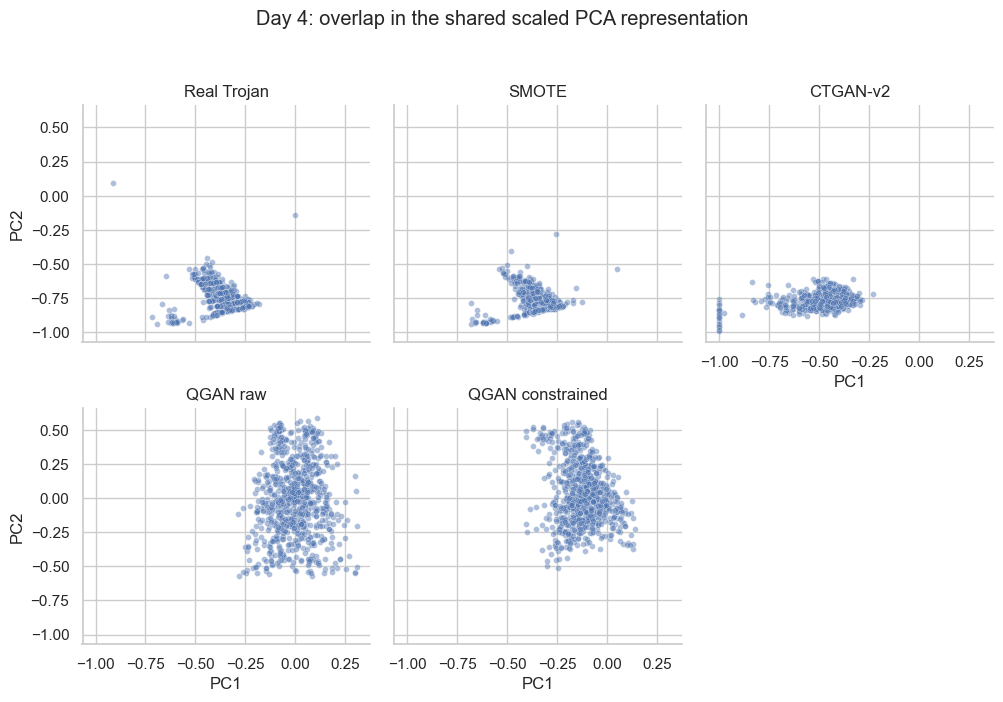

In [14]:
visualization_methods = {
    "Real Trojan": real_scaled_pca,
    "SMOTE": spaces["SMOTE"]["scaled_pca"],
    "CTGAN-v2": spaces["CTGAN-v2"]["scaled_pca"],
    "QGAN raw": spaces["QGAN raw"]["scaled_pca"],
    "QGAN constrained": spaces["QGAN constrained"]["scaled_pca"],
}

plot_rows = []
for method, values in visualization_methods.items():
    rng = np.random.default_rng(SEED)
    selected = rng.choice(len(values), min(750, len(values)), replace=False)
    selected_values = values[selected]
    for row in selected_values:
        plot_rows.append({"method": method, "PC1": row[0], "PC2": row[1]})
pca_plot_df = pd.DataFrame(plot_rows)

g = sns.FacetGrid(pca_plot_df, col="method", col_wrap=3, height=3.4, sharex=True, sharey=True)
g.map_dataframe(sns.scatterplot, x="PC1", y="PC2", alpha=0.45, s=18)
g.set_titles("{col_name}")
g.fig.suptitle("Day 4: overlap in the shared scaled PCA representation", y=1.03)
g.tight_layout()
g.savefig(OUTPUT_DIR / "01_day4_pca_overlap_facets.png", dpi=180, bbox_inches="tight")
plt.show()

t-SNE parameters: {'n_components': 2, 'perplexity': 35, 'learning_rate': 'auto', 'init': 'pca', 'random_state': 42, 'n_iter': 1200}


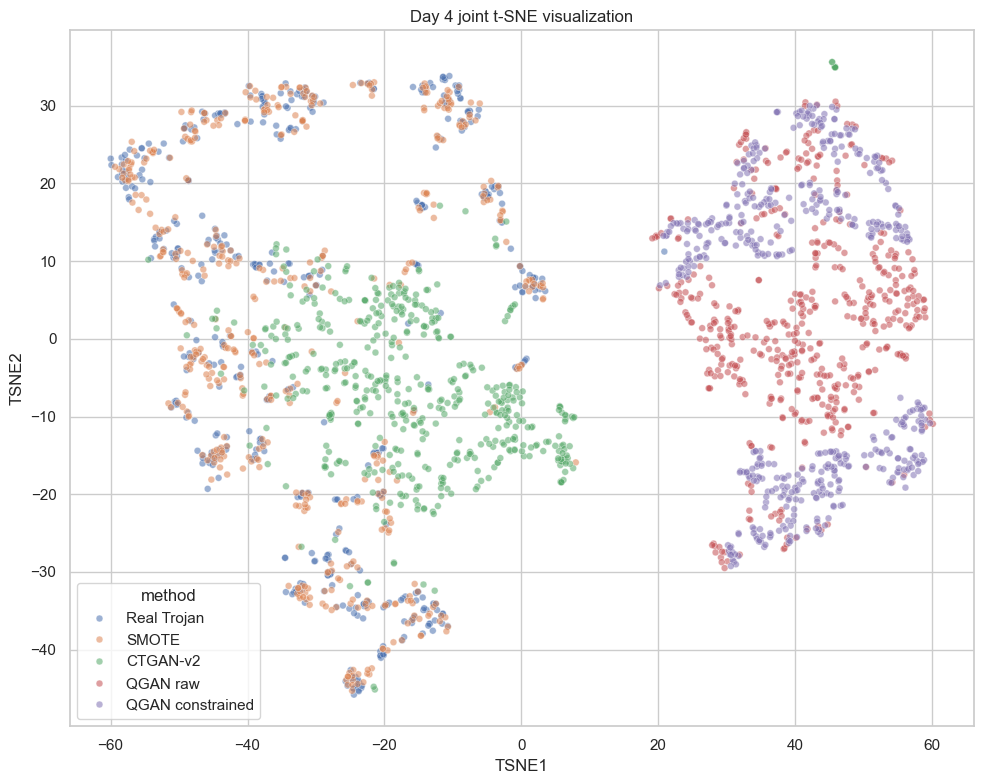

In [15]:
combined_values = []
combined_labels = []

for method, values in visualization_methods.items():
    rng = np.random.default_rng(SEED)
    selected = rng.choice(
        len(values),
        min(500, len(values)),
        replace=False,
    )

    combined_values.append(values[selected])
    combined_labels.extend([method] * len(selected))

combined_values = np.vstack(combined_values)
combined_labels = np.asarray(combined_labels)

import inspect

tsne_parameters = {
    "n_components": 2,
    "perplexity": 35,
    "learning_rate": "auto",
    "init": "pca",
    "random_state": SEED,
}

if "max_iter" in inspect.signature(TSNE).parameters:
    tsne_parameters["max_iter"] = 1200
else:
    tsne_parameters["n_iter"] = 1200

tsne = TSNE(**tsne_parameters)

print("t-SNE parameters:", tsne_parameters)

tsne_embedding = tsne.fit_transform(combined_values)

tsne_df = pd.DataFrame({
    "TSNE1": tsne_embedding[:, 0],
    "TSNE2": tsne_embedding[:, 1],
    "method": combined_labels,
})

plt.figure(figsize=(10, 8))

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="method",
    alpha=0.55,
    s=24,
)

plt.title("Day 4 joint t-SNE visualization")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "02_day4_tsne_overlap.png",
    dpi=180,
    bbox_inches="tight",
)

plt.show()

In [16]:
try:
    import umap

    reducer = umap.UMAP(
        n_neighbors=25,
        min_dist=0.15,
        n_components=2,
        metric="euclidean",
        random_state=SEED,
    )
    umap_embedding = reducer.fit_transform(combined_values)
    umap_df = pd.DataFrame({
        "UMAP1": umap_embedding[:, 0],
        "UMAP2": umap_embedding[:, 1],
        "method": combined_labels,
    })

    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=umap_df, x="UMAP1", y="UMAP2", hue="method", alpha=0.55, s=24)
    plt.title("Day 4 joint UMAP visualization")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "03_day4_umap_overlap.png", dpi=180, bbox_inches="tight")
    plt.show()
except Exception as error:
    print("UMAP skipped:", repr(error))

UMAP skipped: TypeError("check_array() got an unexpected keyword argument 'ensure_all_finite'")


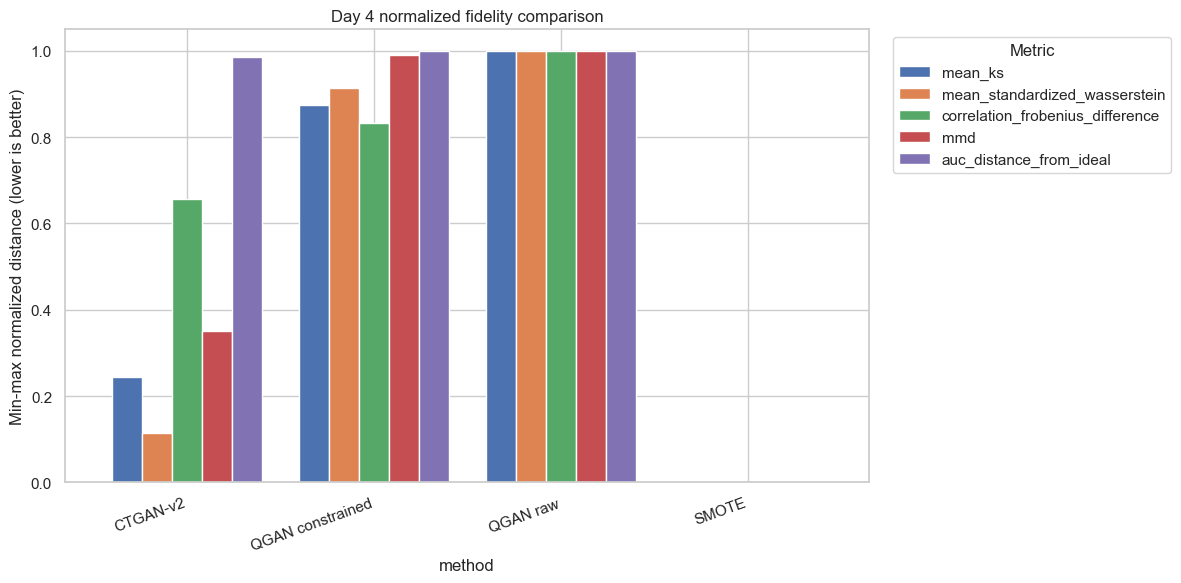

In [17]:
chart_metrics = [
    "mean_ks", "mean_standardized_wasserstein",
    "correlation_frobenius_difference", "mmd", "auc_distance_from_ideal",
]
chart_df = summary_df.set_index("method")[chart_metrics]
normalized_chart = (chart_df - chart_df.min()) / (chart_df.max() - chart_df.min()).replace(0, 1)

ax = normalized_chart.plot(kind="bar", figsize=(12, 6), width=0.8)
ax.set_ylabel("Min-max normalized distance (lower is better)")
ax.set_title("Day 4 normalized fidelity comparison")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_day4_metric_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

## 9. Save report-ready summary



In [18]:
result_records = json.loads(summary_df.to_json(orient="records"))
winner_records = json.loads(winners_df.to_json(orient="records"))

report_summary = {
    "purpose": "Day 4 QGAN vs CTGAN-v2 vs SMOTE fidelity evaluation",
    "dataset_sha256": observed_hash,
    "target_class": TARGET_CLASS,
    "observations_per_method": N_EVAL,
    "real_reference": "exact reconstruction of the Day 3 selected Trojan training subset",
    "day3_baseline": {
        "best_epoch": day3_summary["best_epoch"],
        "mean_ks_scaled_pca": day3_summary["mean_ks_statistic"],
        "mean_wasserstein_scaled_pca": day3_summary["mean_wasserstein_distance"],
        "final_diversity_ratio": day3_summary["instability_monitor"]["final_diversity_ratio"],
        "raw_range_violation_rows": day3_summary["range_violations_before_constraints"][
            "rows_with_any_range_violation"
        ],
    },
    "method_provenance": provenance,
    "summary_metrics": result_records,
    "metric_winners": winner_records,
    "interpretation_constraints": [
        "QGAN raw and QGAN constrained are reported separately.",
        "A constrained output cannot erase raw-generator validity failures.",
        "t-SNE and UMAP are qualitative only.",
        "SMOTE interpolation and generative sampling are not equivalent mechanisms.",
        "No downstream classifier utility claim is made on Day 4.",
    ],
}

with open(OUTPUT_DIR / "day4_summary.json", "w", encoding="utf-8") as file:
    json.dump(report_summary, file, indent=2)

print("Artifacts saved to:", OUTPUT_DIR.resolve())
print("Best method by metric:")
display(winners_df)

Artifacts saved to: C:\Users\HP\Desktop\Qintern\Week3\Day4-7\outputs_days4_7
Best method by metric:


,metric,best_method,best_value
0,mean_ks,SMOTE,0.031596
1,mean_standardized_wasserstein,SMOTE,0.031832
2,correlation_frobenius_difference,SMOTE,0.229730
3,mmd,SMOTE,0.040598
4,auc_distance_from_ideal,SMOTE,0.128089
5,median_synthetic_to_real_nn,SMOTE,0.007891
6,median_real_to_synthetic_nn,SMOTE,0.005380
7,range_violation_row_rate,QGAN constrained,0.000000


## Day 4 reporting template

> Day 4 compared 2,000 observations from QGAN raw, QGAN constrained, CTGAN-v2 and SMOTE against the exact real Trojan subset used on Day 3. All methods were aligned to the same 52 retained features and the same eight-component Day 3 representation. Achieved the lowest mean KS statistic, while some method obtained the lowest MMD. QGAN raw showed a range-violation row rate, compared with after Day 3 constraints.

# Day 5 — Fast downstream utility benchmark

Day 5 tests whether augmentation improves classification on untouched validation and test partitions. All methods append exactly 2,000 Trojan observations to the same stratified real-training subset. QGAN uses the constrained export; the raw export is excluded from classifier training because every raw row violated at least one Day 3 training range.

To keep execution practical, the fast profile uses at most 30,000 real training rows, 100 boosting/tree iterations and a linear SVM. These settings are fixed before test evaluation and are not claimed to be fully optimized.

In [19]:
from scipy.special import softmax
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, average_precision_score, f1_score,
    matthews_corrcoef, roc_auc_score,
)
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.svm import LinearSVC

FAST_CONFIG = {
    "max_real_train_rows": 30000,
    "augmentation_rows": 2000,
    "rf_trees": 100,
    "boosting_iterations": 100,
    "quick_ablation_samples": 256,
    "quick_ablation_epochs": 4,
    "run_quick_quantum_ablation": True,
    "seed": SEED,
}
FAST_CONFIG

{'max_real_train_rows': 30000,
 'augmentation_rows': 2000,
 'rf_trees': 100,
 'boosting_iterations': 100,
 'quick_ablation_samples': 256,
 'quick_ablation_epochs': 4,
 'run_quick_quantum_ablation': True,
 'seed': 42}

In [20]:
label_encoder = LabelEncoder().fit(train_frame[TARGET])
class_names = label_encoder.classes_.tolist()
trojan_encoded = int(label_encoder.transform([TARGET_CLASS])[0])

def classifier_space(frame):
    aligned, _ = align_features(frame)
    return preprocessing["standard_scaler"].transform(aligned)

X_train_all = classifier_space(train_frame)
y_train_all = label_encoder.transform(train_frame[TARGET])

validation_frame = real_clean.loc[val_idx].reset_index(drop=True)
test_frame = real_clean.loc[test_idx].reset_index(drop=True)
X_validation = classifier_space(validation_frame)
y_validation = label_encoder.transform(validation_frame[TARGET])
X_test = classifier_space(test_frame)
y_test = label_encoder.transform(test_frame[TARGET])

max_rows = FAST_CONFIG["max_real_train_rows"]
if len(X_train_all) > max_rows:
    selected_train, _ = train_test_split(
        np.arange(len(X_train_all)),
        train_size=max_rows,
        stratify=y_train_all,
        random_state=SEED,
    )
    X_train_base = X_train_all[selected_train]
    y_train_base = y_train_all[selected_train]
else:
    X_train_base = X_train_all
    y_train_base = y_train_all

augmentation_standard = {
    "SMOTE": spaces["SMOTE"]["standard"],
    "CTGAN-v2": spaces["CTGAN-v2"]["standard"],
    "QGAN constrained": spaces["QGAN constrained"]["standard"],
}

training_variants = {"Original": (X_train_base, y_train_base)}
for method, synthetic_values in augmentation_standard.items():
    n_add = min(FAST_CONFIG["augmentation_rows"], len(synthetic_values))
    selected = np.random.default_rng(SEED).choice(len(synthetic_values), n_add, replace=False)
    X_augmented = np.vstack([X_train_base, synthetic_values[selected]])
    y_augmented = np.concatenate([
        y_train_base,
        np.full(n_add, trojan_encoded, dtype=int),
    ])
    training_variants[method] = (X_augmented, y_augmented)

print("Classes:", class_names)
print("Base train shape:", X_train_base.shape)
print("Validation / test:", X_validation.shape, X_test.shape)
print({method: values[0].shape for method, values in training_variants.items()})

Classes: ['Benign', 'Ransomware', 'Spyware', 'Trojan']
Base train shape: (30000, 52)
Validation / test: (8710, 52) (8710, 52)
{'Original': (30000, 52), 'SMOTE': (32000, 52), 'CTGAN-v2': (32000, 52), 'QGAN constrained': (32000, 52)}


In [21]:
try:
    from xgboost import XGBClassifier
    xgboost_available = True
except Exception as error:
    print("XGBoost unavailable; HistGradientBoosting fallback will be used:", repr(error))
    xgboost_available = False

try:
    from lightgbm import LGBMClassifier
    lightgbm_available = True
except Exception as error:
    print("LightGBM unavailable; HistGradientBoosting fallback will be used:", repr(error))
    lightgbm_available = False

def build_models():
    models = {
        "Random Forest": RandomForestClassifier(
            n_estimators=FAST_CONFIG["rf_trees"],
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced_subsample",
            random_state=SEED,
            n_jobs=-1,
        ),
        "Linear SVM": LinearSVC(
            C=1.0,
            class_weight="balanced",
            dual="auto",
            max_iter=4000,
            random_state=SEED,
        ),
    }

    if xgboost_available:
        models["XGBoost"] = XGBClassifier(
            n_estimators=FAST_CONFIG["boosting_iterations"],
            max_depth=6,
            learning_rate=0.08,
            subsample=0.85,
            colsample_bytree=0.85,
            objective="multi:softprob",
            eval_metric="mlogloss",
            tree_method="hist",
            random_state=SEED,
            n_jobs=-1,
        )
    else:
        models["XGBoost fallback"] = HistGradientBoostingClassifier(
            max_iter=FAST_CONFIG["boosting_iterations"], random_state=SEED
        )

    if lightgbm_available:
        models["LightGBM"] = LGBMClassifier(
            n_estimators=FAST_CONFIG["boosting_iterations"],
            learning_rate=0.08,
            num_leaves=31,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1,
            verbosity=-1,
        )
    else:
        models["LightGBM fallback"] = HistGradientBoostingClassifier(
            max_iter=FAST_CONFIG["boosting_iterations"], random_state=SEED
        )
    return models

XGBoost unavailable; HistGradientBoosting fallback will be used: ModuleNotFoundError("No module named 'xgboost'")


In [22]:
def prediction_scores(model, features):
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(features)
    else:
        decision = model.decision_function(features)
        if decision.ndim == 1:
            decision = np.column_stack([-decision, decision])
        scores = softmax(decision, axis=1)
    return np.asarray(scores)

def evaluate_classifier(model, features, labels):
    predictions = model.predict(features)
    scores = prediction_scores(model, features)
    binary_labels = label_binarize(labels, classes=np.arange(len(class_names)))
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "macro_f1": float(f1_score(labels, predictions, average="macro")),
        "weighted_f1": float(f1_score(labels, predictions, average="weighted")),
        "mcc": float(matthews_corrcoef(labels, predictions)),
        "roc_auc_macro_ovr": float(roc_auc_score(
            binary_labels, scores, average="macro", multi_class="ovr"
        )),
        "pr_auc_macro": float(average_precision_score(binary_labels, scores, average="macro")),
        "trojan_f1": float(f1_score(
            labels, predictions, labels=[trojan_encoded], average="macro", zero_division=0
        )),
    }

benchmark_rows = []
for variant_name, (X_variant, y_variant) in training_variants.items():
    print("\nTraining variant:", variant_name, X_variant.shape)
    for model_name, model in build_models().items():
        start = __import__("time").time()
        model.fit(X_variant, y_variant)
        training_seconds = __import__("time").time() - start

        for split_name, X_split, y_split in [
            ("validation", X_validation, y_validation),
            ("test", X_test, y_test),
        ]:
            row = evaluate_classifier(model, X_split, y_split)
            row.update({
                "training_variant": variant_name,
                "classifier": model_name,
                "split": split_name,
                "training_rows": int(len(X_variant)),
                "training_seconds": float(training_seconds),
            })
            benchmark_rows.append(row)
        print(f"  {model_name}: {training_seconds:.1f}s")

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_df.to_csv(OUTPUT_DIR / "day5_classical_benchmark.csv", index=False)
display(
    benchmark_df[benchmark_df.split.eq("test")]
    .sort_values("macro_f1", ascending=False)
    .round(5)
)


Training variant: Original (30000, 52)
  Random Forest: 1.1s
  Linear SVM: 38.2s
  XGBoost fallback: 1.9s
  LightGBM: 0.8s

Training variant: SMOTE (32000, 52)
  Random Forest: 1.2s
  Linear SVM: 51.9s
  XGBoost fallback: 2.0s
  LightGBM: 0.8s

Training variant: CTGAN-v2 (32000, 52)
  Random Forest: 1.2s
  Linear SVM: 5.6s
  XGBoost fallback: 2.1s
  LightGBM: 0.8s

Training variant: QGAN constrained (32000, 52)
  Random Forest: 1.2s
  Linear SVM: 12.2s
  XGBoost fallback: 2.1s
  LightGBM: 0.9s


,accuracy,macro_f1,weighted_f1,mcc,roc_auc_macro_ovr,pr_auc_macro,trojan_f1,training_variant,classifier,split,training_rows,training_seconds
9,0.86315,0.79326,0.86325,0.79428,0.96701,0.86348,0.71004,SMOTE,Random Forest,test,32000,1.16852
7,0.86303,0.79273,0.86297,0.79383,0.96484,0.85520,0.70323,Original,LightGBM,test,30000,0.84896
29,0.86292,0.79234,0.86271,0.79369,0.96573,0.85816,0.70701,QGAN constrained,XGBoost fallback,test,32000,2.11409
25,0.86257,0.79193,0.86239,0.79319,0.96495,0.85603,0.69534,QGAN constrained,Random Forest,test,32000,1.15789
1,0.86154,0.79068,0.86157,0.79159,0.96574,0.85865,0.69924,Original,Random Forest,test,30000,1.12411
21,0.86131,0.78995,0.86113,0.79126,0.96540,0.85775,0.70568,CTGAN-v2,XGBoost fallback,test,32000,2.06874
17,0.86005,0.78835,0.86002,0.78936,0.96507,0.85694,0.69140,CTGAN-v2,Random Forest,test,32000,1.18907
15,0.85993,0.78805,0.85985,0.78917,0.96487,0.85488,0.70107,SMOTE,LightGBM,test,32000,0.83082
5,0.85970,0.78757,0.85956,0.78883,0.96556,0.85784,0.70107,Original,XGBoost fallback,test,30000,1.93304
13,0.85924,0.78666,0.85894,0.78890,0.96618,0.86005,0.71276,SMOTE,XGBoost fallback,test,32000,2.04814


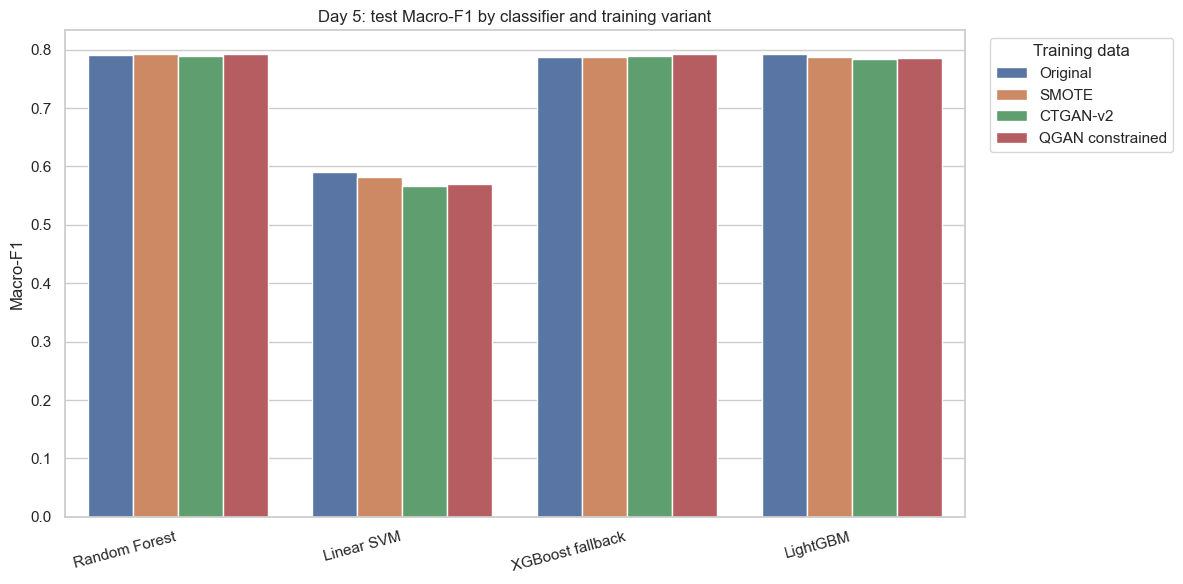

,training_variant,mean_macro_f1,mean_mcc,mean_pr_auc
1,Original,0.74039,0.74376,0.79982
3,SMOTE,0.73749,0.74605,0.80063
2,QGAN constrained,0.73507,0.74322,0.79464
0,CTGAN-v2,0.73206,0.73706,0.78830


In [23]:
test_benchmark = benchmark_df[benchmark_df.split.eq("test")].copy()
plt.figure(figsize=(12, 6))
sns.barplot(
    data=test_benchmark,
    x="classifier",
    y="macro_f1",
    hue="training_variant",
)
plt.title("Day 5: test Macro-F1 by classifier and training variant")
plt.xlabel("")
plt.ylabel("Macro-F1")
plt.xticks(rotation=15, ha="right")
plt.legend(title="Training data", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_day5_macro_f1.png", dpi=180, bbox_inches="tight")
plt.show()

best_test_row = test_benchmark.loc[test_benchmark.macro_f1.idxmax()]
method_average_df = (
    test_benchmark.groupby("training_variant")
    .agg(mean_macro_f1=("macro_f1", "mean"), mean_mcc=("mcc", "mean"), mean_pr_auc=("pr_auc_macro", "mean"))
    .reset_index()
    .sort_values("mean_macro_f1", ascending=False)
)
method_average_df.to_csv(OUTPUT_DIR / "day5_method_average_metrics.csv", index=False)
display(method_average_df.round(5))

# Day 6 — Quick QGAN ablation

This is a bounded engineering sensitivity check, not a replacement for the Day 3 full run. Three configurations are trained for four epochs on 256 real Trojan observations. The objective is to compare directionally whether circuit depth, update ratio and instance noise affect short-run stability.



In [24]:
# pip install torch torchvision torchaudio

In [25]:
import time
import pennylane as qml
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

In [26]:
# %pip install torch

# import time
# import pennylane as qml
# import torch
# from torch import nn
# from torch.utils.data import DataLoader, TensorDataset

class QuickPatchGenerator(nn.Module):
    def __init__(self, n_layers):
        super().__init__()
        self.n_patches = 2
        self.n_qubits = 4
        self.n_layers = n_layers
        self.weights = nn.Parameter(0.15 * torch.randn(2, n_layers, 4, 2))
        device = qml.device("default.qubit", wires=4, shots=None)

        def qfunc(noise, weights):
            qml.AngleEmbedding(torch.pi * noise, wires=range(4), rotation="Y")
            for layer in range(n_layers):
                for wire in range(4):
                    qml.RY(weights[layer, wire, 0], wires=wire)
                    qml.RZ(weights[layer, wire, 1], wires=wire)
                for wire in range(4):
                    qml.CNOT(wires=[wire, (wire + 1) % 4])
            return [qml.expval(qml.PauliZ(wire)) for wire in range(4)]

        self.single = qml.QNode(qfunc, device, interface="torch", diff_method="backprop")
        self.batch = qml.batch_input(self.single, argnum=0)
        self.batch_active = True

    @staticmethod
    def as_matrix(result, batch_size):
        value = torch.stack(list(result), dim=-1) if isinstance(result, (tuple, list)) else result
        if value.ndim == 1:
            value = value.unsqueeze(0)
        if value.shape[0] != batch_size and value.shape[-1] == batch_size:
            value = value.transpose(0, 1)
        return value.to(torch.float32)

    def patch_forward(self, noise, weights):
        if self.batch_active:
            try:
                return self.as_matrix(self.batch(noise, weights), len(noise))
            except Exception as error:
                print("Batch fallback:", repr(error))
                self.batch_active = False
        rows = [self.as_matrix(self.single(sample, weights), 1).squeeze(0) for sample in noise]
        return torch.stack(rows)

    def forward(self, noise):
        return torch.cat([
            self.patch_forward(noise, self.weights[patch]) for patch in range(2)
        ], dim=1)


class QuickDiscriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(8, 16), nn.LeakyReLU(0.2),
            nn.Dropout(0.15), nn.Linear(16, 8),
            nn.LeakyReLU(0.2), nn.Linear(8, 1),
        )

    def forward(self, values):
        return self.network(values)

In [27]:
QUICK_ABLATIONS = [
    {"run": "A", "layers": 2, "g_updates": 1, "instance_noise": 0.00, "g_lr": 0.005, "d_lr": 0.0001},
    {"run": "B", "layers": 3, "g_updates": 2, "instance_noise": 0.08, "g_lr": 0.005, "d_lr": 0.0001},
    {"run": "C", "layers": 3, "g_updates": 2, "instance_noise": 0.08, "g_lr": 0.003, "d_lr": 0.0002},
]

def run_quick_ablation(configuration):
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    rng = np.random.default_rng(SEED)
    selected = rng.choice(
        len(real_scaled_pca),
        FAST_CONFIG["quick_ablation_samples"],
        replace=False,
    )
    real_values = torch.tensor(real_scaled_pca[selected], dtype=torch.float32)
    loader = DataLoader(
        TensorDataset(real_values), batch_size=64, shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )

    generator = QuickPatchGenerator(configuration["layers"])
    discriminator = QuickDiscriminator()
    optimizer_g = torch.optim.Adam(generator.parameters(), lr=configuration["g_lr"], betas=(0.5, 0.9))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=configuration["d_lr"], betas=(0.5, 0.9))
    criterion = nn.BCEWithLogitsLoss()
    start = time.time()
    final_d_loss = final_g_loss = np.nan

    for epoch in range(FAST_CONFIG["quick_ablation_epochs"]):
        current_noise = configuration["instance_noise"] * (
            1 - epoch / max(FAST_CONFIG["quick_ablation_epochs"], 1)
        )
        for (real_batch,) in loader:
            batch_size = len(real_batch)
            optimizer_d.zero_grad(set_to_none=True)
            latent = 2 * torch.rand(batch_size, 4) - 1
            fake = generator(latent).detach()
            real_input = torch.clamp(real_batch + current_noise * torch.randn_like(real_batch), -1, 1)
            fake_input = torch.clamp(fake + current_noise * torch.randn_like(fake), -1, 1)
            real_targets = torch.empty(batch_size, 1).uniform_(0.85, 1.0)
            fake_targets = torch.empty(batch_size, 1).uniform_(0.0, 0.15)
            d_loss = 0.5 * (
                criterion(discriminator(real_input), real_targets)
                + criterion(discriminator(fake_input), fake_targets)
            )
            d_loss.backward()
            torch.nn.utils.clip_grad_norm_(discriminator.parameters(), 2.0)
            optimizer_d.step()

            for parameter in discriminator.parameters():
                parameter.requires_grad_(False)
            for _ in range(configuration["g_updates"]):
                optimizer_g.zero_grad(set_to_none=True)
                latent = 2 * torch.rand(batch_size, 4) - 1
                generated = generator(latent)
                targets = torch.empty(batch_size, 1).uniform_(0.85, 1.0)
                g_loss = criterion(discriminator(generated), targets)
                g_loss.backward()
                torch.nn.utils.clip_grad_norm_(generator.parameters(), 2.0)
                optimizer_g.step()
            for parameter in discriminator.parameters():
                parameter.requires_grad_(True)

            final_d_loss = float(d_loss.detach())
            final_g_loss = float(g_loss.detach())

    with torch.no_grad():
        latent = 2 * torch.rand(len(real_values), 4) - 1
        synthetic = generator(latent).numpy()

    real_array = real_values.numpy()
    mean_ks = float(np.mean([
        ks_2samp(real_array[:, component], synthetic[:, component]).statistic
        for component in range(8)
    ]))
    diversity_ratio = float(
        synthetic.std(axis=0).mean() / max(real_array.std(axis=0).mean(), 1e-12)
    )
    mean_gap = float(np.abs(synthetic.mean(axis=0) - real_array.mean(axis=0)).mean())
    return {
        **configuration,
        "epochs": FAST_CONFIG["quick_ablation_epochs"],
        "samples": len(real_values),
        "final_d_loss": final_d_loss,
        "final_g_loss": final_g_loss,
        "mean_ks": mean_ks,
        "diversity_ratio": diversity_ratio,
        "mean_gap": mean_gap,
        "training_seconds": time.time() - start,
        "batched_qnode": generator.batch_active,
    }

if FAST_CONFIG["run_quick_quantum_ablation"]:
    quick_ablation_rows = []
    for configuration in QUICK_ABLATIONS:
        print("Running quick ablation", configuration["run"])
        quick_ablation_rows.append(run_quick_ablation(configuration))
    quick_ablation_df = pd.DataFrame(quick_ablation_rows)
else:
    quick_ablation_df = pd.DataFrame([{ "run": "SKIPPED", "reason": "FAST_CONFIG disabled" }])

quick_ablation_df.to_csv(OUTPUT_DIR / "day6_quick_qgan_ablation.csv", index=False)
display(quick_ablation_df.round(5))

Running quick ablation A
Running quick ablation B
Running quick ablation C


,run,layers,g_updates,instance_noise,g_lr,d_lr,epochs,samples,final_d_loss,final_g_loss,mean_ks,diversity_ratio,mean_gap,training_seconds,batched_qnode
0,A,2,1,0.00,0.005,0.0001,4,256,0.68995,0.78194,0.78076,5.31098,0.45092,47.42826,True
1,B,3,2,0.08,0.005,0.0001,4,256,0.69234,0.67088,0.71680,6.74840,0.42484,101.72398,True
2,C,3,2,0.08,0.003,0.0002,4,256,0.69107,0.67141,0.71191,7.01308,0.42415,98.03819,True


# Day 7 — Consolidated report

Day 7 combines fidelity, downstream utility and the bounded ablation. The conclusion distinguishes engineering feasibility, statistical fidelity and classifier utility; it does not claim quantum advantage unless all three forms of evidence support it.

In [28]:
fidelity_candidates = summary_df[summary_df.method.ne("QGAN raw")].copy()
best_ks_row = fidelity_candidates.loc[fidelity_candidates.mean_ks.idxmin()]
best_mmd_row = fidelity_candidates.loc[fidelity_candidates.mmd.idxmin()]
best_auc_row = fidelity_candidates.loc[fidelity_candidates.auc_distance_from_ideal.idxmin()]

best_average_method = method_average_df.iloc[0]
best_classifier_result = best_test_row

if "mean_ks" in quick_ablation_df.columns:
    best_ablation = quick_ablation_df.loc[quick_ablation_df.mean_ks.idxmin()].to_dict()
else:
    best_ablation = {"run": "skipped"}

qgan_fidelity = summary_df[summary_df.method.eq("QGAN constrained")].iloc[0]
ctgan_fidelity = summary_df[summary_df.method.eq("CTGAN-v2")].iloc[0]
smote_fidelity = summary_df[summary_df.method.eq("SMOTE")].iloc[0]

original_macro = float(method_average_df.loc[
    method_average_df.training_variant.eq("Original"), "mean_macro_f1"
].iloc[0])
qgan_macro = float(method_average_df.loc[
    method_average_df.training_variant.eq("QGAN constrained"), "mean_macro_f1"
].iloc[0])

conclusion_category = (
    "engineering feasibility with limited statistical fidelity"
    if qgan_fidelity.mean_ks > min(ctgan_fidelity.mean_ks, smote_fidelity.mean_ks)
    else "competitive QGAN fidelity under the fast protocol"
)

consolidated = {
    "purpose": "Unified Days 4-7 QGAN evaluation",
    "execution_profile": FAST_CONFIG,
    "dataset_sha256": observed_hash,
    "day4": {
        "best_mean_ks_method": best_ks_row.method,
        "best_mean_ks": float(best_ks_row.mean_ks),
        "best_mmd_method": best_mmd_row.method,
        "best_mmd": float(best_mmd_row.mmd),
        "best_two_sample_auc_method": best_auc_row.method,
        "best_two_sample_auc": float(best_auc_row.two_sample_rf_auc),
        "qgan_constrained_mean_ks": float(qgan_fidelity.mean_ks),
        "qgan_raw_range_violation_rate": float(
            summary_df.loc[summary_df.method.eq("QGAN raw"), "range_violation_row_rate"].iloc[0]
        ),
    },
    "day5": {
        "best_average_training_variant": str(best_average_method.training_variant),
        "best_average_macro_f1": float(best_average_method.mean_macro_f1),
        "best_single_classifier": str(best_classifier_result.classifier),
        "best_single_training_variant": str(best_classifier_result.training_variant),
        "best_single_macro_f1": float(best_classifier_result.macro_f1),
        "original_average_macro_f1": original_macro,
        "qgan_average_macro_f1": qgan_macro,
        "qgan_macro_f1_change": qgan_macro - original_macro,
    },
    "day6": {"best_quick_ablation": best_ablation},
    "day7": {
        "conclusion_category": conclusion_category,
        "quantum_advantage_claimed": False,
        "primary_limitation": "small-qubit Patch-QGAN and fast single-seed protocol",
    },
}

with open(OUTPUT_DIR / "days4_7_consolidated_summary.json", "w", encoding="utf-8") as file:
    json.dump(consolidated, file, indent=2, default=float)

print(json.dumps(consolidated, indent=2, default=float))

{
  "purpose": "Unified Days 4-7 QGAN evaluation",
  "execution_profile": {
    "max_real_train_rows": 30000,
    "augmentation_rows": 2000,
    "rf_trees": 100,
    "boosting_iterations": 100,
    "quick_ablation_samples": 256,
    "quick_ablation_epochs": 4,
    "run_quick_quantum_ablation": true,
    "seed": 42
  },
  "dataset_sha256": "cc7a637a174ffe797e0af0375bce3c09561f0dc8b8115c0a6292718034f5012a",
  "day4": {
    "best_mean_ks_method": "SMOTE",
    "best_mean_ks": 0.03159615384615384,
    "best_mmd_method": "SMOTE",
    "best_mmd": 0.04059826041591563,
    "best_two_sample_auc_method": "SMOTE",
    "best_two_sample_auc": 0.628088875,
    "qgan_constrained_mean_ks": 0.7379326923076923,
    "qgan_raw_range_violation_rate": 1.0
  },
  "day5": {
    "best_average_training_variant": "Original",
    "best_average_macro_f1": 0.7403926643776761,
    "best_single_classifier": "Random Forest",
    "best_single_training_variant": "SMOTE",
    "best_single_macro_f1": 0.7932622723921405,
  

## This notebook

The unified notebook produces:

- Day 4 provenance, per-feature, multivariate, validity and summary metric tables;
- PCA, t-SNE, UMAP and normalized metric figures;
- Day 5 complete validation/test classifier table and Macro-F1 figure;
- Day 6 quick QGAN ablation table;
- Day 7 consolidated JSON and plain-text report.